# 01 — 탐색적 데이터 분석 (EDA)
### Tennessee Eastman Process 이상탐지 프로젝트

1. TEP 데이터 로딩 및 기본 구조 확인
2. 정상 vs 이상 데이터 분포 비교
3. 핵심 변수 시계열 시각화
4. 변수 간 상관관계 분석
5. 클래스 불균형 확인
6. Rolling / Diff / Z-score 기반 동적 EDA

---
**실행 전 확인:**
- `data/raw/` 폴더에 TEP CSV 4개


## 0. 환경 설정

In [16]:
import sys, os

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('환경 설정 완료')
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__} | numpy: {np.__version__}')


환경 설정 완료
Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
pandas: 2.2.0 | numpy: 1.26.4


## 1. 데이터 로딩

`src/data_loader.py`의 `load_tep()`를 사용  
이상 유형 **1, 2, 4, 5**만 사용 — 탐지 난이도가 섞여 있음  
(fault 4·5는 평균값 변화가 작아 동적 피처가 특히 중요)


In [17]:
from src.data_loader import (
    load_tep, get_X_y, get_fault_subset,
    FEATURE_COLS, XMEAS_COLS, XMV_COLS,
    ZONE_VARS, FAULT_DESC
)

FAULT_TYPES = [1, 2, 4, 5]

train_df, test_df = load_tep(
    data_dir='../data/raw',
    fault_types=FAULT_TYPES,
    verbose=True
)


  로딩 완료: TEP_FaultFree_Training.csv  (250000, 55)
  로딩 완료: TEP_FaultFree_Testing.csv  (480000, 55)
  로딩 완료: TEP_Faulty_Training.csv  (5000000, 55)
  로딩 완료: TEP_Faulty_Testing.csv  (9600000, 55)

TEP 데이터 로딩 완료

[학습]  총 1,250,000행  |  정상: 250,000  |  이상: 1,000,000  (80.0%)

[테스트]  총 2,400,000행  |  정상: 480,000  |  이상: 1,920,000  (80.0%)

사용한 이상 유형: [1, 2, 4, 5]
이상 유형 설명:
  fault  1: A/C 피드 비율 이상 (Step)
  fault  2: B 성분 조성 이상 (Step)
  fault  4: 반응기 냉각수 입구온도 이상 (Step)
  fault  5: 냉각기 냉각수 입구온도 이상 (Step)


## 2. 기본 구조 확인

In [37]:
print('=== 학습 데이터 기본 정보 ===')
print(f'shape       : {train_df.shape}')
print(f'컬럼 수      : {len(train_df.columns)}개')
print(f'피처 컬럼 수 : {len(FEATURE_COLS)}개')
print()
print('컬럼 목록:')
print(train_df.columns.tolist())


=== 학습 데이터 기본 정보 ===
shape       : (1250000, 56)
컬럼 수      : 56개
피처 컬럼 수 : 52개

컬럼 목록:
['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11', 'label']


In [38]:
train_df.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,xmeas_11,xmeas_12,xmeas_13,xmeas_14,xmeas_15,xmeas_16,xmeas_17,xmeas_18,xmeas_19,xmeas_20,xmeas_21,xmeas_22,xmeas_23,xmeas_24,xmeas_25,xmeas_26,xmeas_27,xmeas_28,xmeas_29,xmeas_30,xmeas_31,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41,xmv_1,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,label
0,0.0000,1.0000,1,0.2504,3674.0000,4529.0000,9.2320,26.8890,42.4020,2704.3000,74.8630,120.4100,0.3382,80.0440,51.4350,2632.9000,25.0290,50.5280,3101.1000,22.8190,65.7320,229.6100,341.2200,94.6400,77.0470,32.1880,8.8933,26.3830,6.8820,18.7760,1.6567,32.9580,13.8230,23.9780,1.2565,18.5790,2.2633,4.8436,2.2986,0.0179,0.8357,0.0986,53.7240,43.8280,62.8810,53.7440,24.6570,62.5440,22.1370,39.9350,42.3230,47.7570,47.5100,41.2580,18.4470,0
1,0.0000,1.0000,2,0.2511,3659.4000,4556.6000,9.4264,26.7210,42.5760,2705.0000,75.0000,120.4100,0.3362,80.0780,50.1540,2633.8000,24.4190,48.7720,3102.0000,23.3330,65.7160,230.5400,341.3000,94.5950,77.4340,32.1880,8.8933,26.3830,6.8820,18.7760,1.6567,32.9580,13.8230,23.9780,1.2565,18.5790,2.2633,4.8436,2.2986,0.0179,0.8357,0.0986,53.7240,43.8280,63.1320,53.4140,24.5880,59.2590,22.0840,40.1760,38.5540,43.6920,47.4270,41.3590,17.1940,0
2,0.0000,1.0000,3,0.2504,3660.3000,4477.8000,9.4426,26.8750,42.0700,2706.2000,74.7710,120.4200,0.3356,80.2200,50.3020,2635.5000,25.2440,50.0710,3103.5000,21.9240,65.7320,230.0800,341.3800,94.6050,77.4660,31.7670,8.7694,26.0950,6.8259,18.9610,1.6292,32.9850,13.7420,23.8970,1.3001,18.7650,2.2602,4.8543,2.3900,0.0179,0.8357,0.0986,53.7240,43.8280,63.1170,54.3570,24.6660,61.2750,22.3800,40.2440,38.9900,46.6990,47.4680,41.1990,20.5300,0
3,0.0000,1.0000,4,0.2498,3661.3000,4512.1000,9.4776,26.7580,42.0630,2707.2000,75.2240,120.3900,0.3355,80.3050,49.9900,2635.6000,23.2680,50.4350,3102.8000,22.9480,65.7810,227.9100,341.7100,94.4730,77.4430,31.7670,8.7694,26.0950,6.8259,18.9610,1.6292,32.9850,13.7420,23.8970,1.3001,18.7650,2.2602,4.8543,2.3900,0.0179,0.8357,0.0986,53.7240,43.8280,63.1000,53.9460,24.7250,59.8560,22.2770,40.2570,38.0720,47.5410,47.6580,41.6430,18.0890,0
4,0.0000,1.0000,5,0.2940,3679.0000,4497.0000,9.3381,26.8890,42.6500,2705.1000,75.3880,120.3900,0.3263,80.0640,51.3100,2632.4000,26.0990,50.4800,3103.5000,22.8080,65.7880,231.3700,341.1100,94.6780,76.9470,32.3220,8.5821,26.7690,6.8688,18.7820,1.6396,33.0710,13.8340,24.2280,1.0938,18.6660,2.2193,4.8304,2.2416,0.0179,0.8357,0.0986,53.7240,43.8280,63.3130,53.6580,28.7970,60.7170,21.9470,39.1440,41.9550,47.6450,47.3460,41.5070,18.4610,0


In [39]:
# 기술 통계 — 스케일 차이 파악 (전처리 시 StandardScaler 근거)
train_df[FEATURE_COLS].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
xmeas_1,1250000.0000,0.3540,0.2070,0.0170,0.2400,0.2690,0.3140,1.0180
xmeas_2,1250000.0000,3667.9070,37.8910,3472.5000,3642.4000,3667.6000,3693.2000,3844.7000
xmeas_3,1250000.0000,4529.2220,83.5560,4160.3000,4480.1000,4517.4000,4567.2000,4852.4000
xmeas_4,1250000.0000,9.2890,0.3030,7.8450,9.2210,9.3450,9.4610,10.0160
xmeas_5,1250000.0000,26.9020,0.2120,25.9480,26.7580,26.9020,27.0460,27.8230
xmeas_6,1250000.0000,42.3850,0.2700,41.1910,42.2000,42.3760,42.5610,43.6110
xmeas_7,1250000.0000,2706.0960,21.0200,2617.8000,2696.5000,2704.4000,2712.1000,2842.8000
xmeas_8,1250000.0000,75.0120,0.7810,70.4200,74.5660,74.9990,75.4390,79.7230
xmeas_9,1250000.0000,120.4000,0.0200,120.3000,120.3900,120.4000,120.4100,120.6100
xmeas_10,1250000.0000,0.3990,0.1440,0.2200,0.3260,0.3390,0.3560,0.8210


In [40]:
missing = train_df[FEATURE_COLS].isnull().sum()
print('결측값 있는 컬럼:')
print(missing[missing > 0] if missing.sum() > 0 else '결측값 없음 (정상)')


결측값 있는 컬럼:
결측값 없음 (정상)


## 3. 클래스 분포 확인

정상/이상 비율을 확인.  
불균형이 심하면 학습 시 `class_weight='balanced'` 또는 SMOTE 적용 고려.


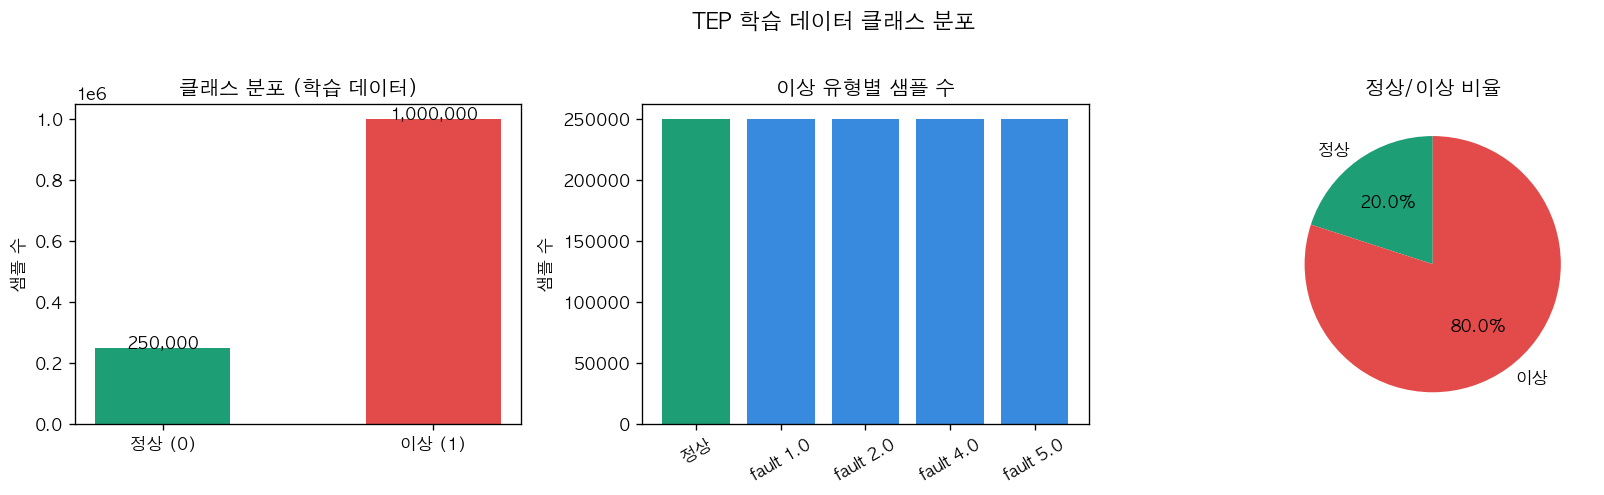


클래스 불균형 비율: 1:4.00 (정상:이상)


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_counts = train_df['label'].value_counts().reindex([0, 1])
axes[0].bar(
    ['정상 (0)', '이상 (1)'],
    label_counts.values,
    color=['#1D9E75', '#E24B4A'],
    width=0.5
)
axes[0].set_title('클래스 분포 (학습 데이터)')
axes[0].set_ylabel('샘플 수')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

fault_counts = train_df['faultNumber'].value_counts().sort_index()
colors = ['#1D9E75'] + ['#378ADD'] * len(FAULT_TYPES)
axes[1].bar(
    [f'fault {i}' if i > 0 else '정상' for i in fault_counts.index],
    fault_counts.values,
    color=colors
)
axes[1].set_title('이상 유형별 샘플 수')
axes[1].set_ylabel('샘플 수')
axes[1].tick_params(axis='x', rotation=30)

axes[2].pie(
    label_counts.values,
    labels=['정상', '이상'],
    autopct='%1.1f%%',
    colors=['#1D9E75', '#E24B4A'],
    startangle=90
)
axes[2].set_title('정상/이상 비율')

plt.suptitle('TEP 학습 데이터 클래스 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n클래스 불균형 비율: 1:{label_counts[1]/label_counts[0]:.2f} (정상:이상)')


## 4. 핵심 변수 시계열 시각화

| 변수 | 공정 위치 | 비고 |
|------|----------|------|
| xmeas_7 | 반응기 압력 | fault 1·2에서 변화 관찰됨 |
| xmeas_9 | 반응기 온도 | **평균 변화 작음** — 동적 피처 필요 |
| xmeas_11 | 생성물 유량 | 수율 직결 |
| xmeas_17 | 분리기 온도 | **평균 변화 작음** — 동적 피처 필요 |


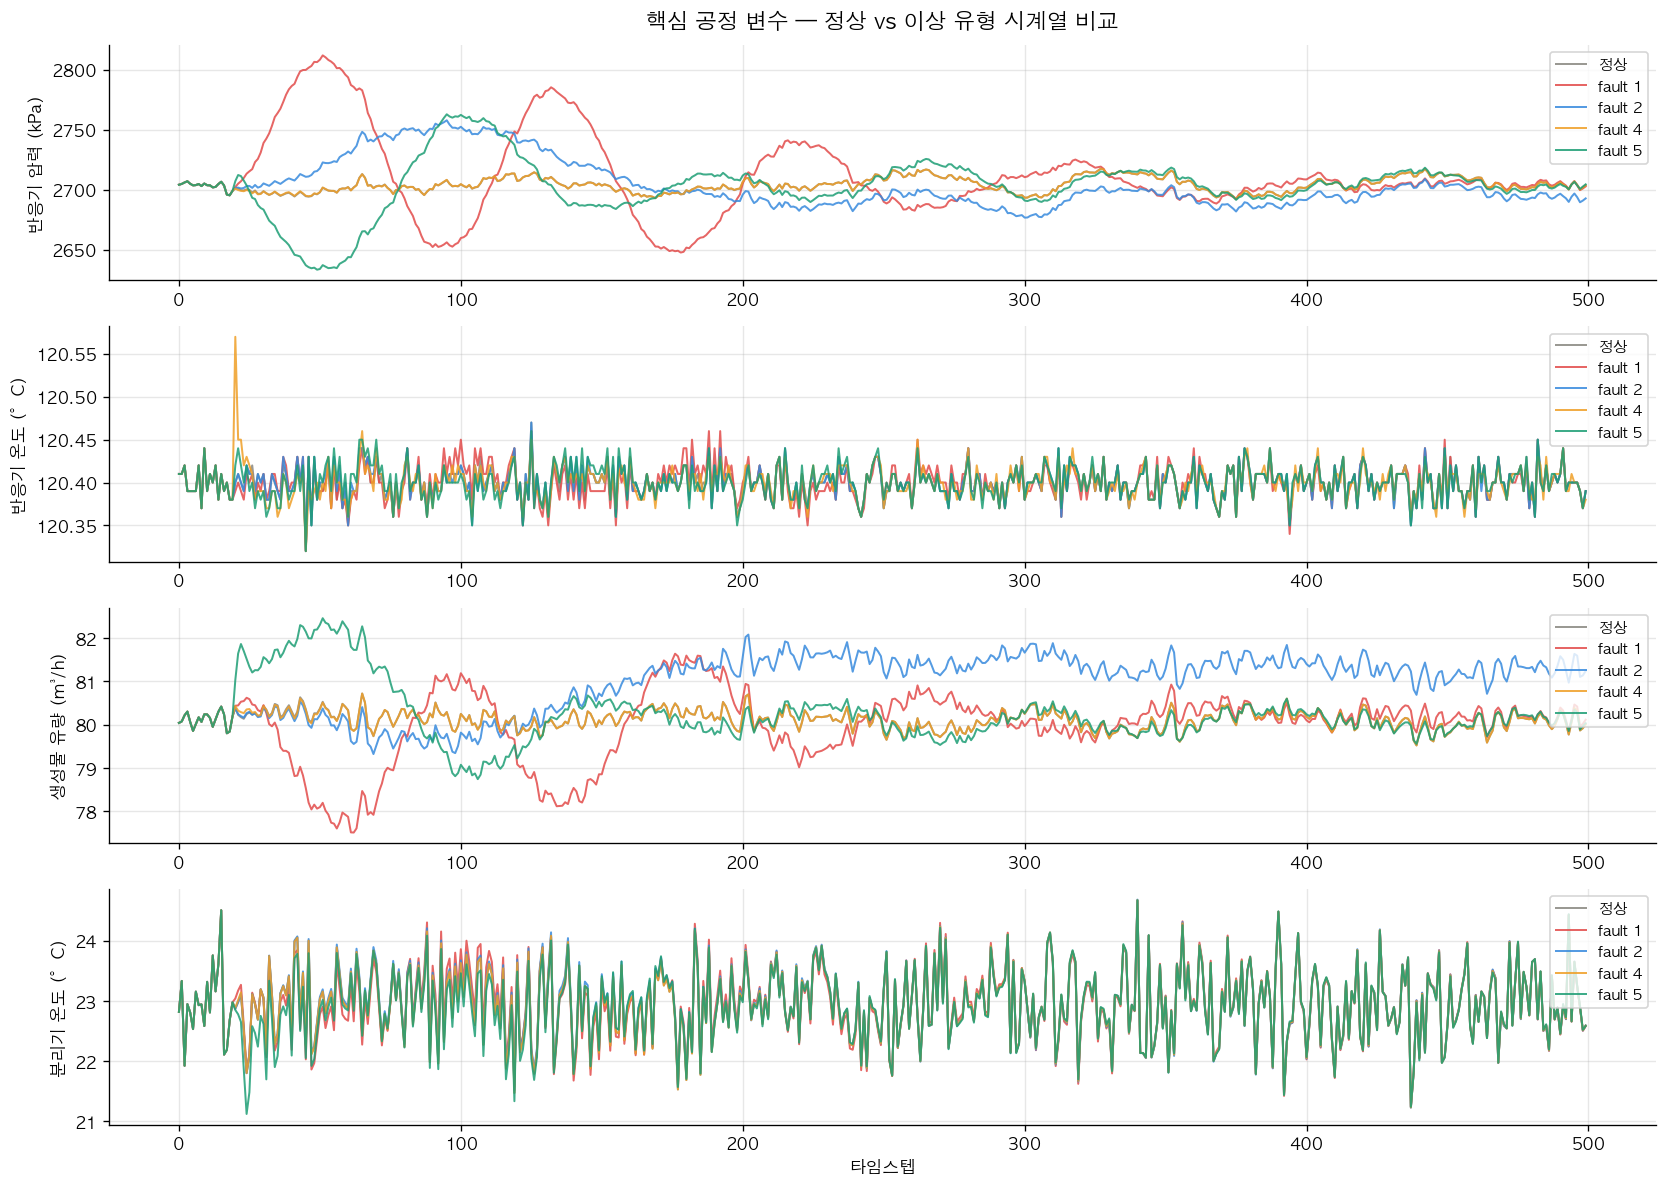

시각화 저장: outputs/01_timeseries_comparison.png


In [42]:
KEY_VARS = {
    'xmeas_7':  '반응기 압력 (kPa)',
    'xmeas_9':  '반응기 온도 (°C)',
    'xmeas_11': '생성물 유량 (m³/h)',
    'xmeas_17': '분리기 온도 (°C)',
}

COMPARE_FAULTS = [0] + FAULT_TYPES
FAULT_COLORS   = ['#888780', '#E24B4A', '#378ADD', '#EF9F27', '#1D9E75']

def get_run1(df, fault_num):
    sub = df[df['faultNumber'] == fault_num]
    run1 = sub['simulationRun'].iloc[0] if len(sub) > 0 else None
    if run1 is None:
        return pd.DataFrame()
    return sub[sub['simulationRun'] == run1].reset_index(drop=True)

fig, axes = plt.subplots(len(KEY_VARS), 1, figsize=(14, 10))

for ax, (var, label) in zip(axes, KEY_VARS.items()):
    for fault_num, color in zip(COMPARE_FAULTS, FAULT_COLORS):
        run_df = get_run1(train_df, fault_num)
        if var not in run_df.columns or len(run_df) == 0:
            continue
        name = '정상' if fault_num == 0 else f'fault {fault_num}'
        ax.plot(run_df.index, run_df[var], label=name,
                color=color, alpha=0.85, linewidth=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_title('핵심 공정 변수 — 정상 vs 이상 유형 시계열 비교', fontsize=13, pad=10)
axes[-1].set_xlabel('타임스텝', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/01_timeseries_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장: outputs/01_timeseries_comparison.png')


## 5. 이상 유형별 통계 비교

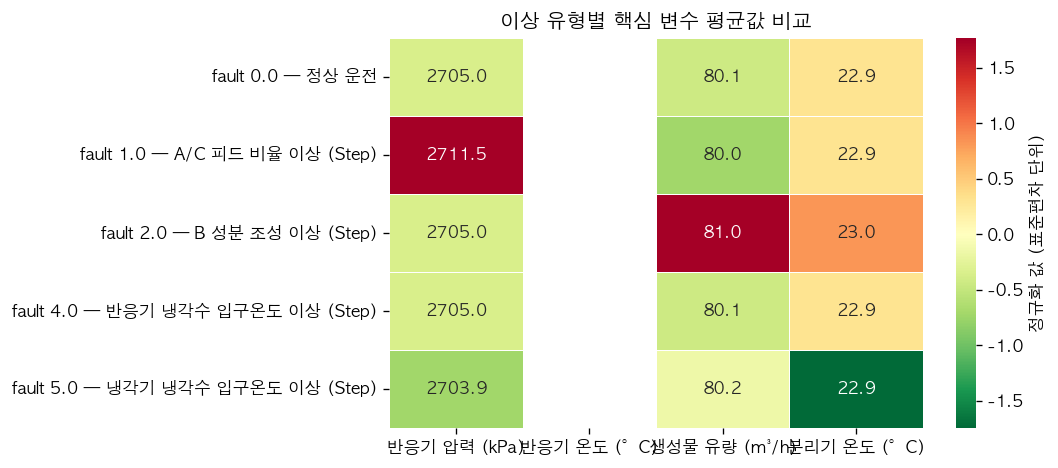

In [43]:
compare_vars = list(KEY_VARS.keys())

summary = (
    train_df
    .groupby('faultNumber')[compare_vars]
    .mean()
    .round(2)
)
summary.index = [
    f'fault {i} — {FAULT_DESC.get(i,"")}' for i in summary.index
]
summary.columns = [KEY_VARS[v] for v in compare_vars]

fig, ax = plt.subplots(figsize=(9, 4))
summary_norm = (summary - summary.mean()) / summary.std()
sns.heatmap(
    summary_norm,
    annot=summary.values,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=0,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '정규화 값 (표준편차 단위)'}
)
ax.set_title('이상 유형별 핵심 변수 평균값 비교', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/01_fault_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [44]:
print('이상 유형별 핵심 변수 평균값:')
summary


이상 유형별 핵심 변수 평균값:


,반응기 압력 (kPa),반응기 온도 (°C),생성물 유량 (m³/h),분리기 온도 (°C)
fault 0.0 — 정상 운전,2705.0400,120.4000,80.1100,22.9500
fault 1.0 — A/C 피드 비율 이상 (Step),2711.4700,120.4000,80.0000,22.9500
fault 2.0 — B 성분 조성 이상 (Step),2705.0200,120.4000,80.9600,22.9600
fault 4.0 — 반응기 냉각수 입구온도 이상 (Step),2705.0400,120.4000,80.1100,22.9500
fault 5.0 — 냉각기 냉각수 입구온도 이상 (Step),2703.9200,120.4000,80.2200,22.9100


## 6. 변수 분포 (Box Plot)

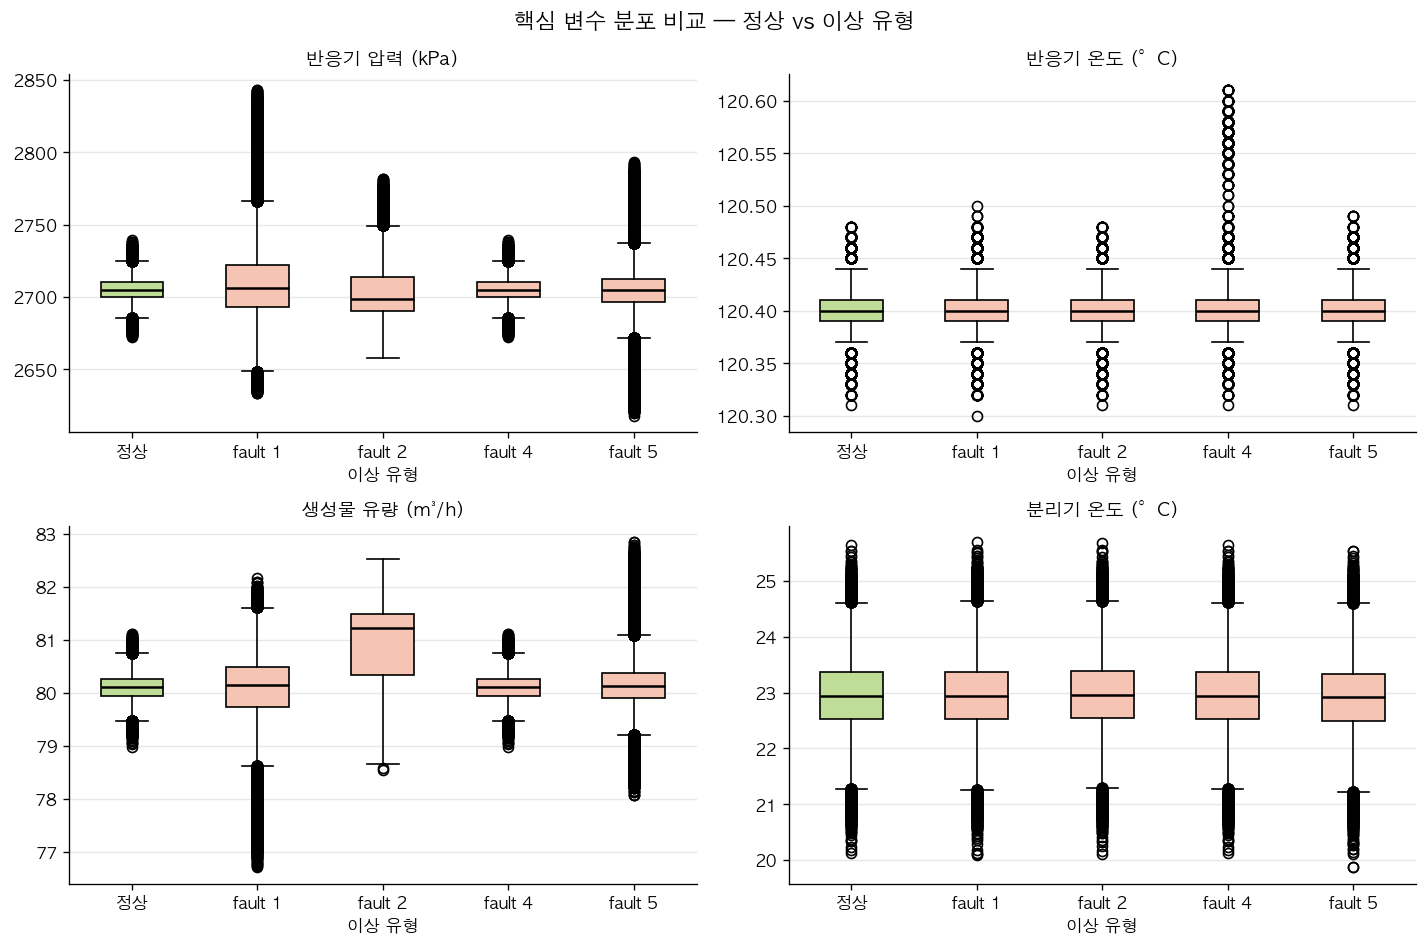

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (var, var_label) in zip(axes, KEY_VARS.items()):
    data_by_fault = [
        train_df[train_df['faultNumber'] == f][var].dropna().values
        for f in COMPARE_FAULTS
    ]
    bp = ax.boxplot(
        data_by_fault,
        labels=['정상'] + [f'fault {f}' for f in FAULT_TYPES],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 1.5}
    )
    bp['boxes'][0].set_facecolor('#C0DD97')
    for box in bp['boxes'][1:]:
        box.set_facecolor('#F5C4B3')
    ax.set_title(var_label, fontsize=11)
    ax.set_xlabel('이상 유형')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('핵심 변수 분포 비교 — 정상 vs 이상 유형', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/01_boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 상관관계 분석

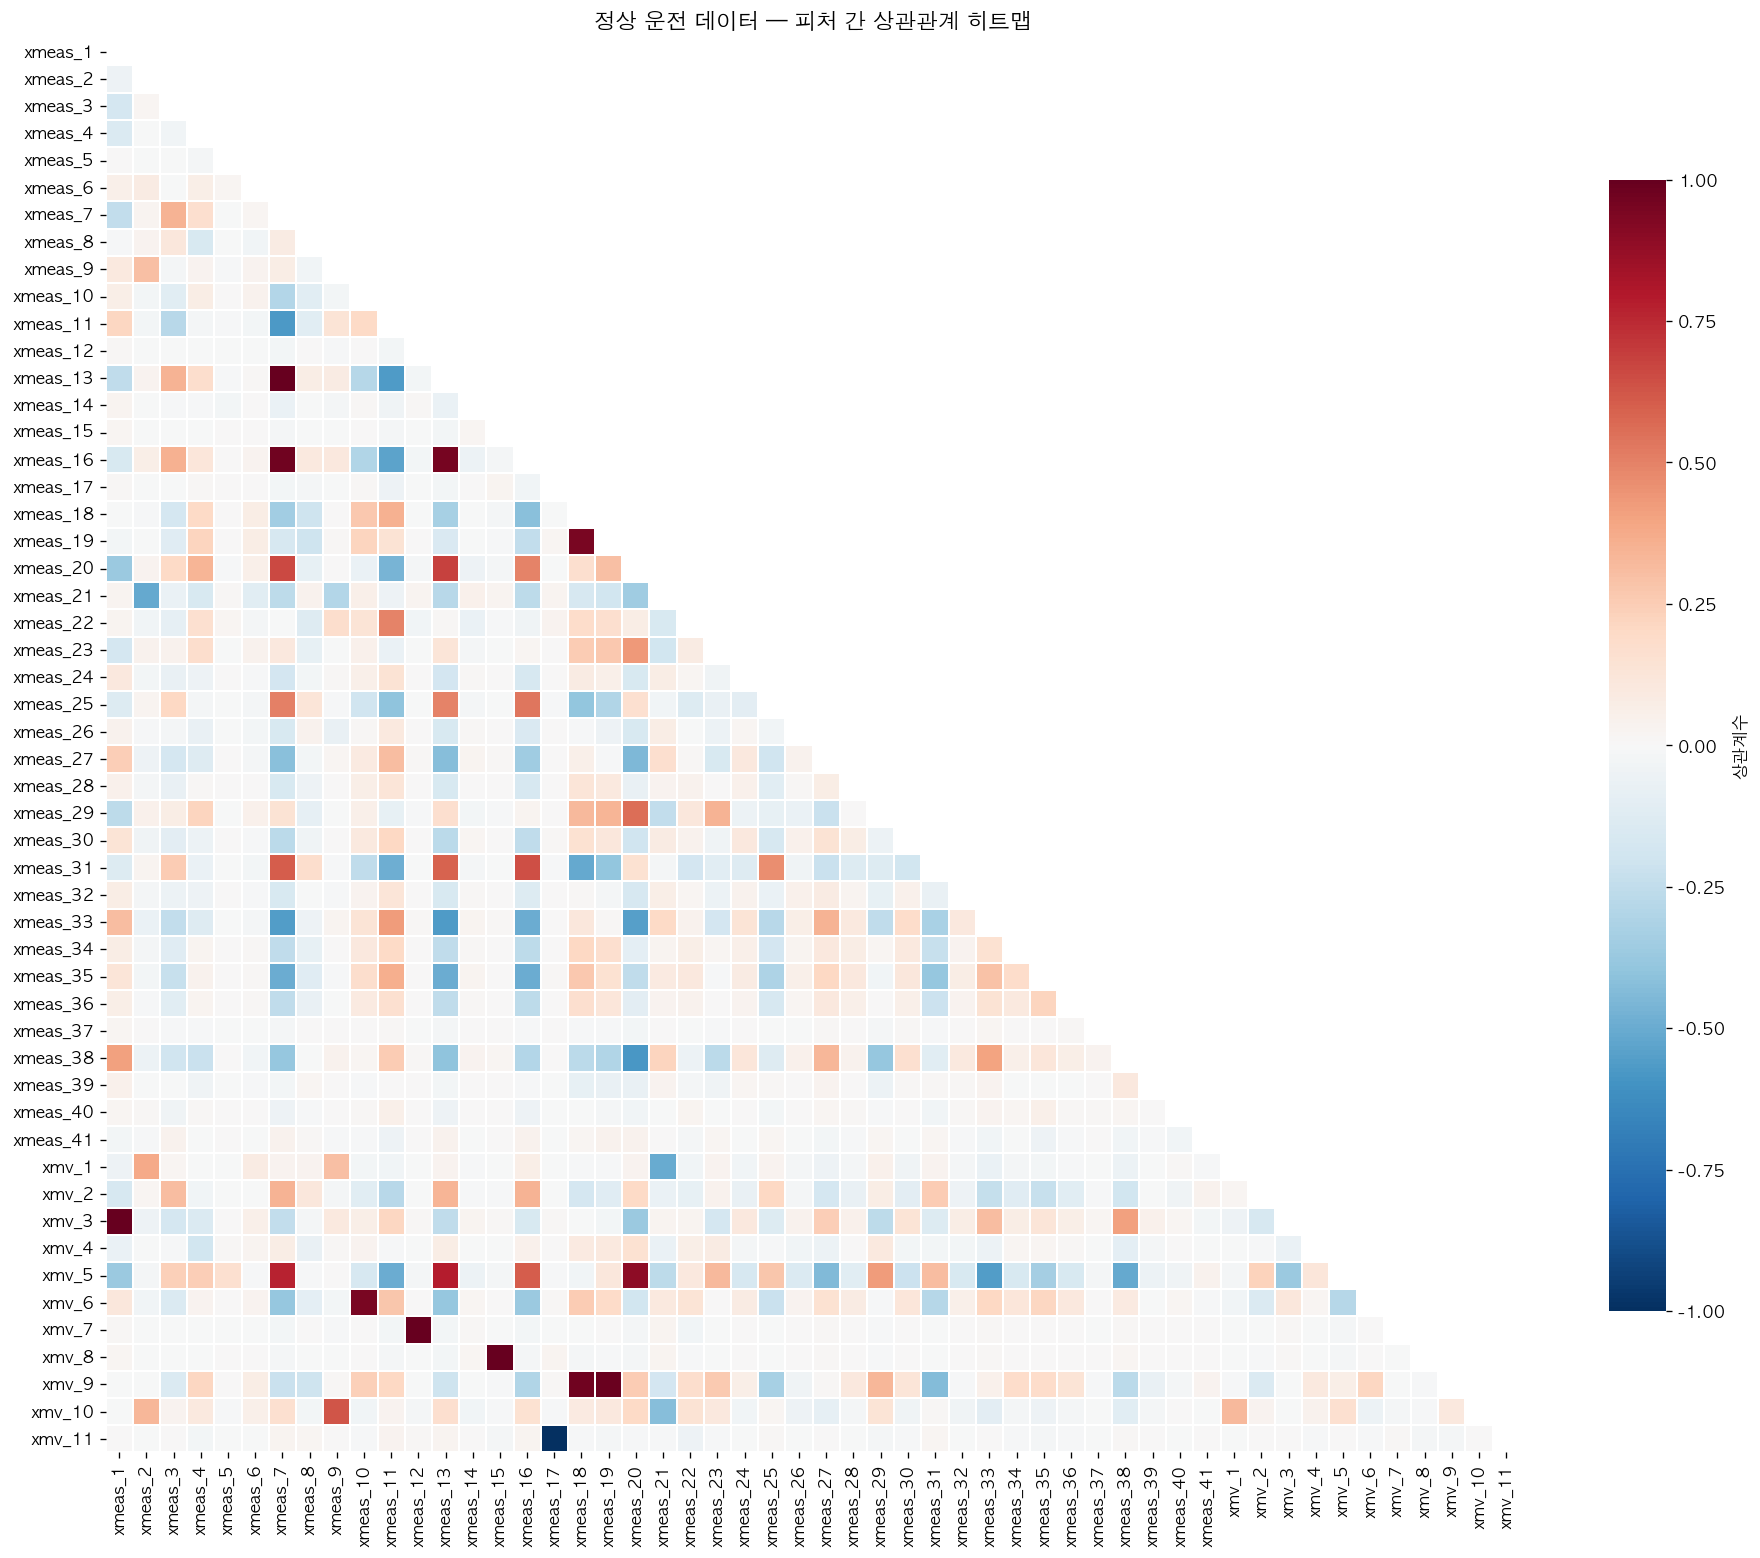


상관계수 |r| > 0.85 변수 쌍: 12개


,변수1,변수2,상관계수
1092,xmv_7,xmeas_12,1.0000
1142,xmv_8,xmeas_15,1.0000
1291,xmv_11,xmeas_17,-0.9992
72,xmeas_13,xmeas_7,0.9974
903,xmv_3,xmeas_1,0.9966
1194,xmv_9,xmeas_19,0.9861
1193,xmv_9,xmeas_18,0.9701
111,xmeas_16,xmeas_7,0.9695
117,xmeas_16,xmeas_13,0.9598
170,xmeas_19,xmeas_18,0.9496


In [46]:
normal_df = train_df[train_df['label'] == 0]
corr = normal_df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.2, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': '상관계수'}
)
ax.set_title('정상 운전 데이터 — 피처 간 상관관계 히트맵', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = (
    corr.where(mask == False)
    .stack()
    .reset_index()
)
high_corr.columns = ['변수1', '변수2', '상관계수']
high_corr = high_corr[high_corr['상관계수'].abs() > 0.85].sort_values(
    '상관계수', key=abs, ascending=False
)
print(f'\n상관계수 |r| > 0.85 변수 쌍: {len(high_corr)}개')
high_corr.head(15)


## 8. 공정 구역별 변수 민감도 분석

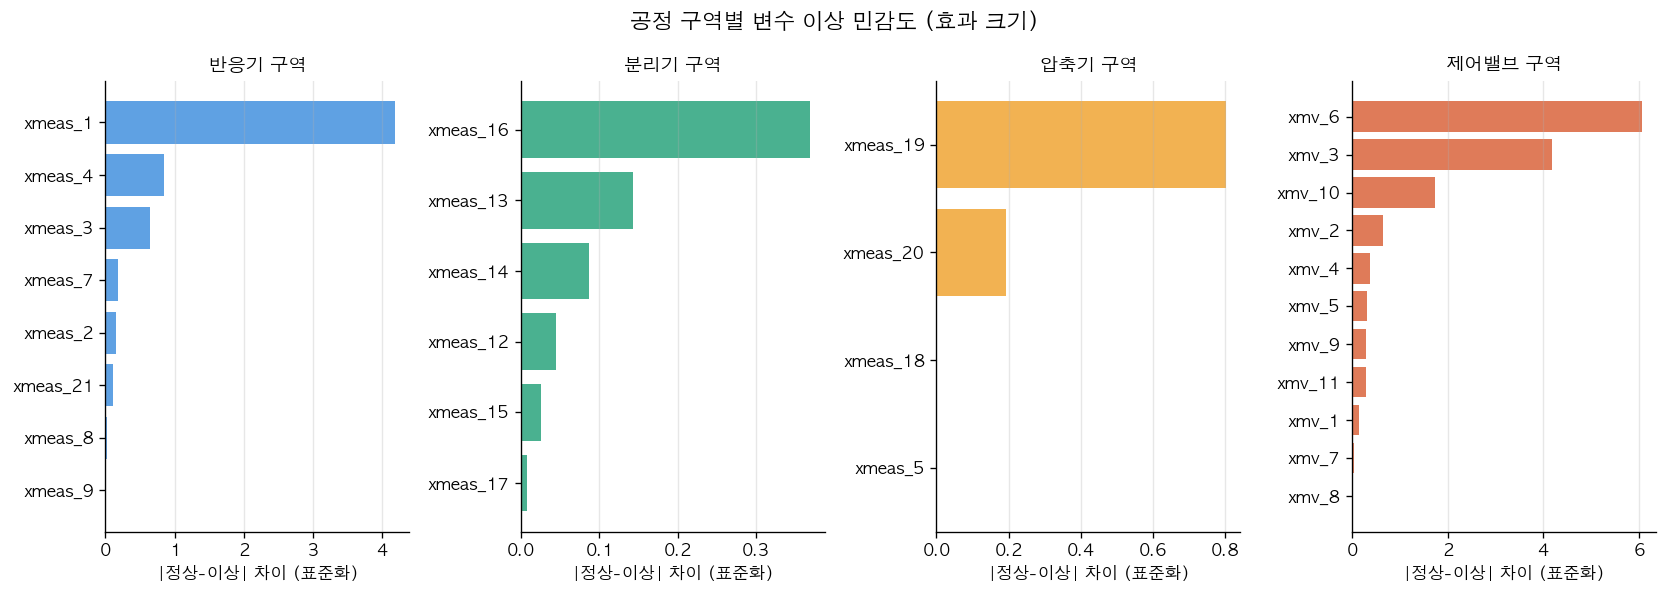


이상 탐지 민감도 상위 10개 변수 (실제 결과 기반):
  xmeas_10     : 6.1952
  xmv_6        : 6.0565
  xmeas_34     : 5.6085
  xmeas_28     : 4.3283
  xmeas_1      : 4.1843
  xmv_3        : 4.1833
  xmv_10       : 1.7373
  xmeas_22     : 1.4156
  xmeas_11     : 0.9098
  xmeas_4      : 0.8416


In [47]:
normal_mean = train_df[train_df['label'] == 0][FEATURE_COLS].mean()
fault_mean  = train_df[train_df['label'] == 1][FEATURE_COLS].mean()
normal_std  = train_df[train_df['label'] == 0][FEATURE_COLS].std()

effect_size = ((fault_mean - normal_mean) / (normal_std + 1e-8)).abs()

fig, axes = plt.subplots(1, len(ZONE_VARS), figsize=(14, 5))
colors_zone = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']

for ax, (zone_name, zone_vars), color in zip(axes, ZONE_VARS.items(), colors_zone):
    available_vars = [v for v in zone_vars if v in effect_size.index]
    zone_effect = effect_size[available_vars].sort_values(ascending=True)
    ax.barh(zone_effect.index, zone_effect.values, color=color, alpha=0.8)
    ax.set_title(f'{zone_name} 구역', fontsize=11)
    ax.set_xlabel('|정상-이상| 차이 (표준화)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('공정 구역별 변수 이상 민감도 (효과 크기)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/01_zone_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n이상 탐지 민감도 상위 10개 변수 (실제 결과 기반):')
top10 = effect_size.sort_values(ascending=False).head(10)
for var, val in top10.items():
    print(f'  {var:12s} : {val:.4f}')


## 9. Rolling · Diff · Z-score 기반 동적 EDA

**목적:** fault 4·5처럼 평균값 변화는 작지만  
분산·추세·이상값 빈도가 달라지는 이상을 잡아내기 위한 동적 피처 탐색.

| 피처 유형 | 계산 방식 | 감지 대상 |
|----------|----------|----------|
| rolling_mean | 이동평균 (w=20) | 완만한 추세 변화 |
| rolling_std | 이동표준편차 (w=20) | 분산 급등 (fault 4·5 핵심) |
| diff | 1-step 차분 | 급격한 점프 |
| z-score | (x - μ) / σ | 정상 분포 대비 이상값 밀도 |


In [48]:
# ── 설정 ──
WINDOW     = 20          # rolling 윈도우 크기 (타임스텝)
FOCUS_VARS = [           # 동적 EDA 집중 변수 (민감도 상위 + 평균변화 작은 것)
    'xmeas_10', 'xmv_6', 'xmeas_34', 'xmeas_28',
    'xmeas_1',  'xmv_3',
    'xmeas_9',  'xmeas_17',   # 평균 변화 작음 → rolling_std 필요
]
FOCUS_VARS = [v for v in FOCUS_VARS if v in FEATURE_COLS]

# ── 동적 피처 계산 함수 ──
def compute_dynamic_features(df, vars_list, window=20):
    """
    simulationRun 단위로 rolling/diff/zscore 계산.
    그룹 경계에서 값이 섞이지 않도록 groupby 적용.
    """
    out = df[['simulationRun', 'faultNumber', 'label']].copy()

    for var in vars_list:
        grp = df.groupby('simulationRun')[var]

        out[f'{var}_rmean'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        out[f'{var}_rstd'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
        out[f'{var}_diff'] = grp.transform(lambda x: x.diff().fillna(0))

        # z-score: 정상 데이터의 μ·σ 기준
        mu  = df.loc[df['label'] == 0, var].mean()
        sig = df.loc[df['label'] == 0, var].std() + 1e-8
        out[f'{var}_zscore'] = (df[var] - mu) / sig

    return out

dynamic_train = compute_dynamic_features(train_df, FOCUS_VARS, window=WINDOW)
print(f'동적 피처 데이터: {dynamic_train.shape}')
print(f'새 피처 예시: {[c for c in dynamic_train.columns if "_rstd" in c][:4]}')


동적 피처 데이터: (1250000, 35)
새 피처 예시: ['xmeas_10_rstd', 'xmv_6_rstd', 'xmeas_34_rstd', 'xmeas_28_rstd']


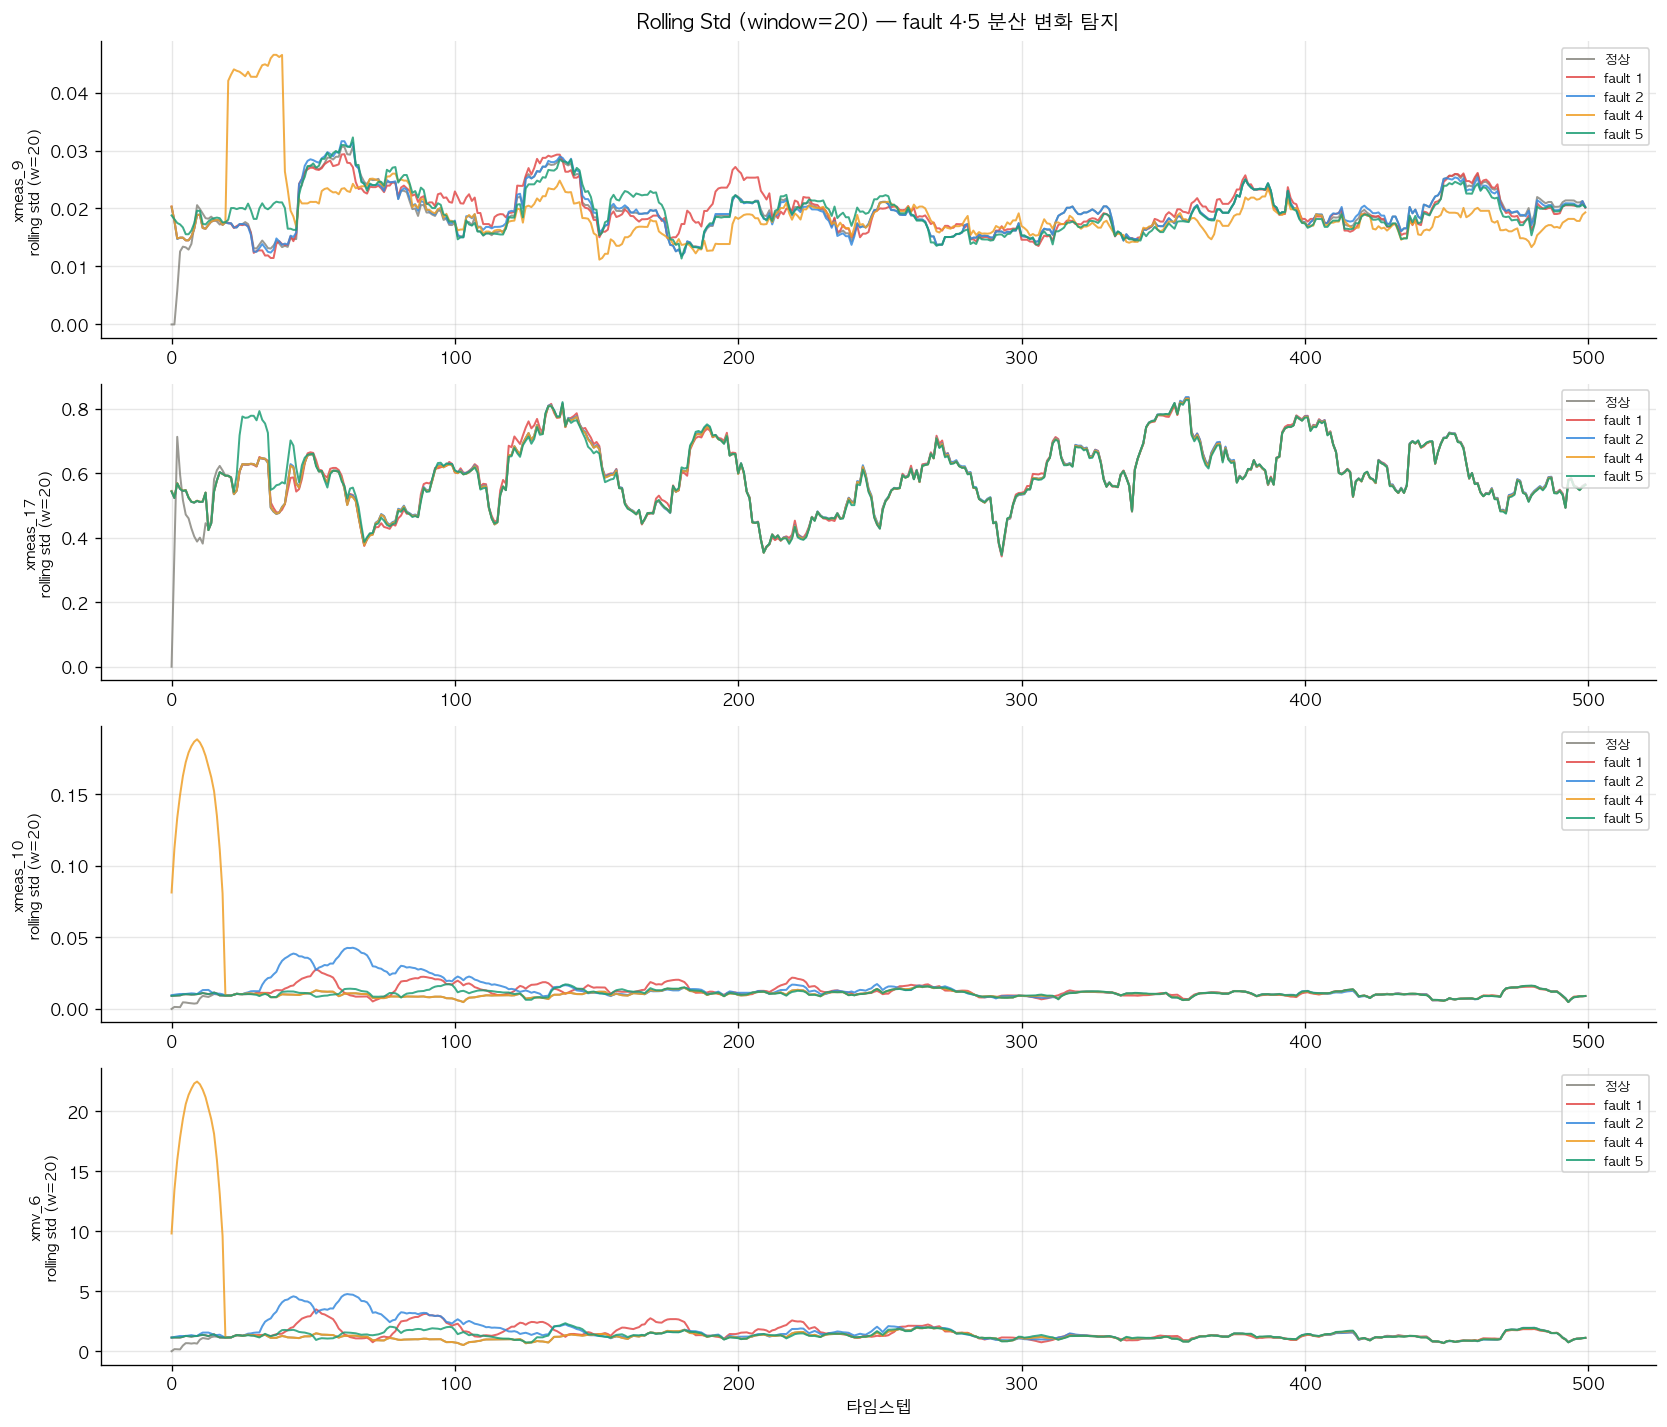

In [50]:
# ── 9-A. Rolling Std 비교 — fault 4·5가 분산이 다른지 확인 ──
RSTD_VARS = [f'{v}_rstd' for v in ['xmeas_9', 'xmeas_17', 'xmeas_10', 'xmv_6']
             if f'{v}_rstd' in dynamic_train.columns]

fig, axes = plt.subplots(len(RSTD_VARS), 1, figsize=(14, 3 * len(RSTD_VARS)))
if len(RSTD_VARS) == 1:
    axes = [axes]

for ax, col in zip(axes, RSTD_VARS):
    for fault_num, color in zip(COMPARE_FAULTS, FAULT_COLORS):
        sub = dynamic_train[dynamic_train['faultNumber'] == fault_num]
        run_id = sub['simulationRun'].iloc[0] if len(sub) > 0 else None
        if run_id is None:
            continue
        run_data = sub[sub['simulationRun'] == run_id].reset_index(drop=True)
        name = '정상' if fault_num == 0 else f'fault {fault_num}'
        ax.plot(run_data.index, run_data[col],
                label=name, color=color, alpha=0.85, linewidth=1.2)

    base_var = col.replace('_rstd', '')
    ax.set_ylabel(f'{base_var}\nrolling std (w={WINDOW})', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_title(f'Rolling Std (window={WINDOW}) — fault 4·5 분산 변화 탐지',
                  fontsize=12, pad=8)
axes[-1].set_xlabel('타임스텝')
plt.tight_layout()
plt.savefig('../outputs/01_rolling_std_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


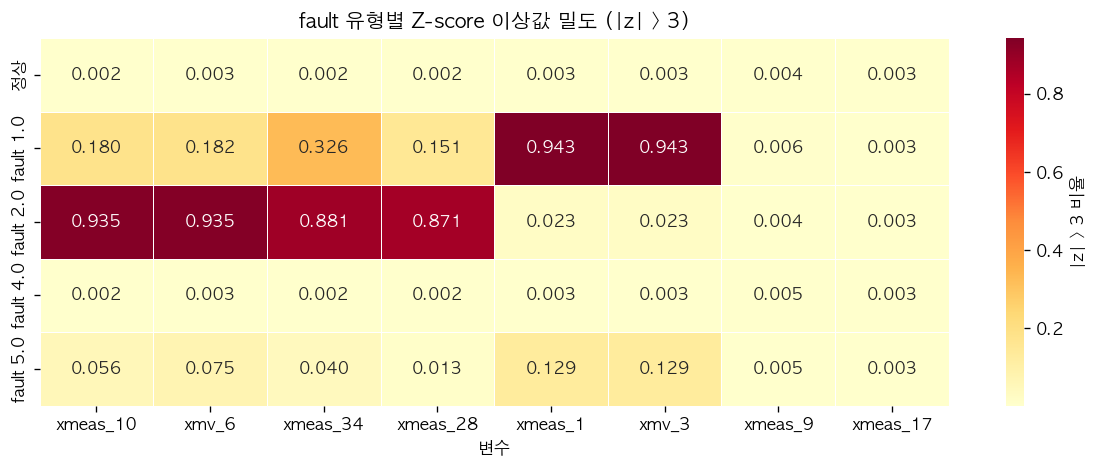


정상 대비 fault 구간에서 Z-score 이상값 밀도가 증가한 변수 Top 10:
xmeas_34   0.3100
xmv_6      0.2961
xmeas_10   0.2908
xmeas_1    0.2717
xmv_3      0.2717
xmeas_28   0.2571
xmeas_9    0.0013
xmeas_17   0.0002
dtype: float64


In [56]:
# ── 9-B. Z-score 이상값 밀도 — fault별 |z| > 3 비율 ──
zscore_cols = [c for c in dynamic_train.columns if c.endswith('_zscore')]

outlier_rate = (
    dynamic_train
    .groupby('faultNumber')[zscore_cols]
    .apply(lambda g: (g.abs() > 3).mean())
)
outlier_rate.index = [
    '정상' if i == 0 else f'fault {i}' for i in outlier_rate.index
]
outlier_rate.columns = [c.replace('_zscore', '') for c in outlier_rate.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    outlier_rate,
    annot=True, fmt='.3f', cmap='YlOrRd',
    ax=ax, linewidths=0.5,
    cbar_kws={'label': '|z| > 3 비율'}
)
ax.set_title('fault 유형별 Z-score 이상값 밀도 (|z| > 3)', fontsize=12)
ax.set_xlabel('변수')
plt.tight_layout()
plt.savefig('../outputs/01_zscore_outlier_density.png', dpi=150, bbox_inches='tight')
plt.show()


fault_rate = outlier_rate.drop(index='정상').mean(axis=0)
diff_rate = fault_rate - outlier_rate.loc['정상']
print('\n정상 대비 fault 구간에서 Z-score 이상값 밀도가 증가한 변수 Top 10:')
print(diff_rate.sort_values(ascending=False).head(10))

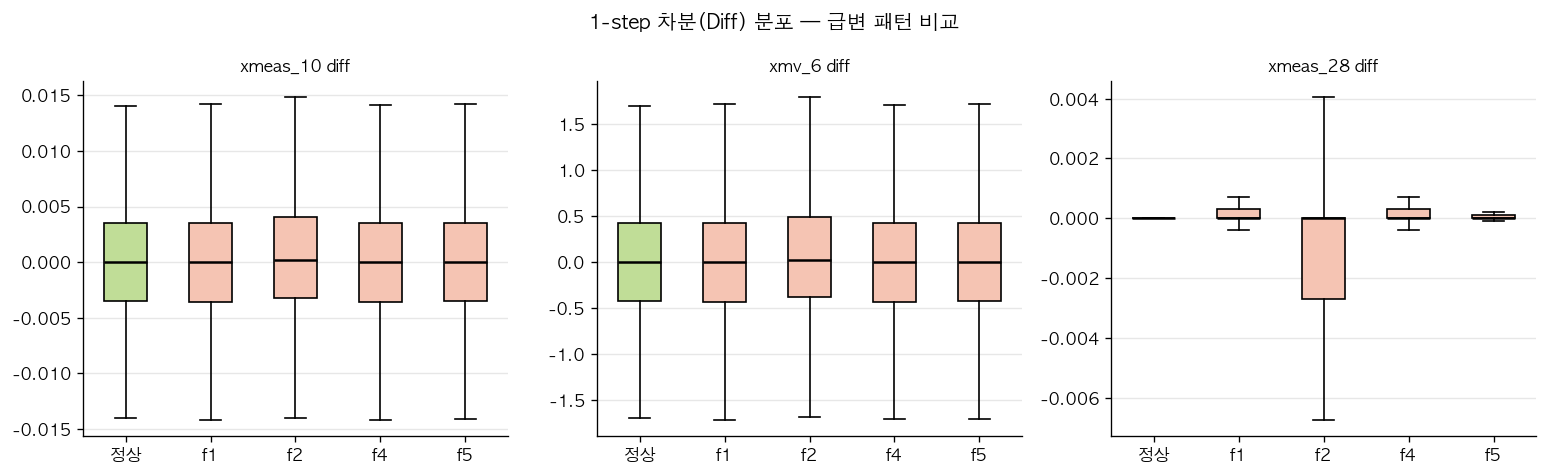

In [52]:
# ── 9-C. Diff (1-step 차분) 분포 — 급변 감지 ──
DIFF_VARS = [f'{v}_diff' for v in ['xmeas_10', 'xmv_6', 'xmeas_28']
             if f'{v}_diff' in dynamic_train.columns]

fig, axes = plt.subplots(1, len(DIFF_VARS), figsize=(13, 4))
if len(DIFF_VARS) == 1:
    axes = [axes]

for ax, col in zip(axes, DIFF_VARS):
    data_by_fault = [
        dynamic_train[dynamic_train['faultNumber'] == f][col].dropna().values
        for f in COMPARE_FAULTS
    ]
    bp = ax.boxplot(
        data_by_fault,
        labels=['정상'] + [f'f{f}' for f in FAULT_TYPES],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 1.5},
        showfliers=False
    )
    bp['boxes'][0].set_facecolor('#C0DD97')
    for box in bp['boxes'][1:]:
        box.set_facecolor('#F5C4B3')

    base_var = col.replace('_diff', '')
    ax.set_title(f'{base_var} diff', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('1-step 차분(Diff) 분포 — 급변 패턴 비교', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/01_diff_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


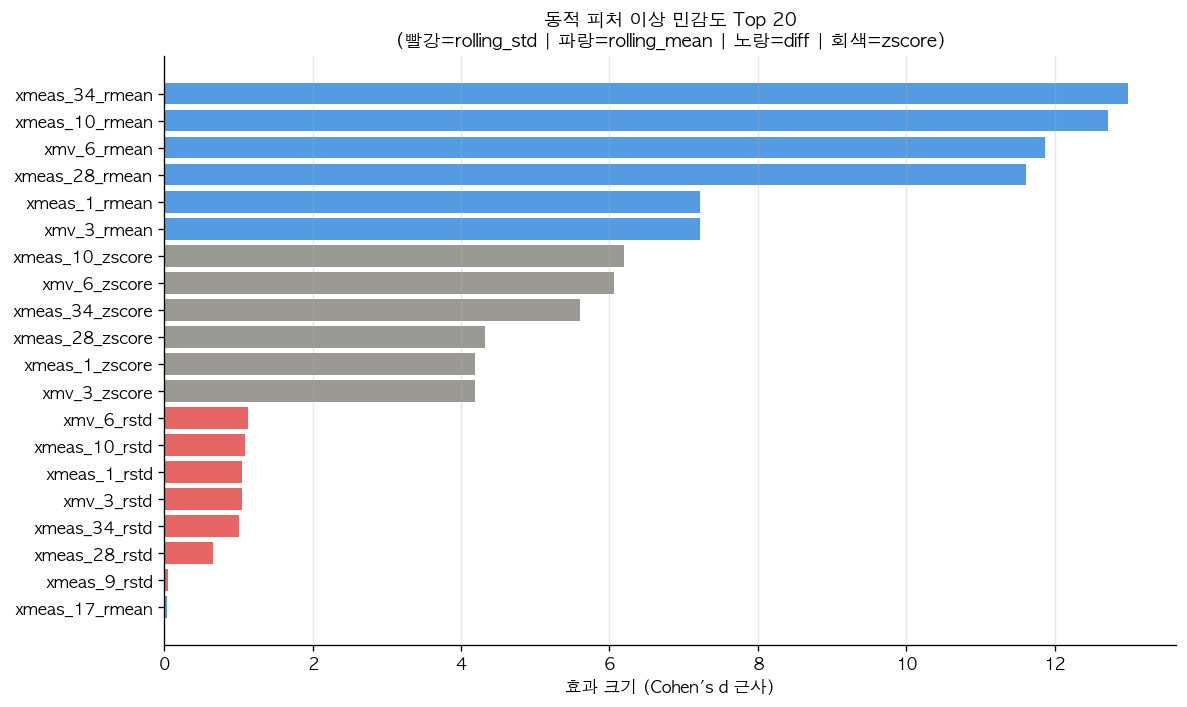


동적 피처 효과크기 상위 10개:
  xmeas_34_rmean                 : 12.9874
  xmeas_10_rmean                 : 12.7165
  xmv_6_rmean                    : 11.8725
  xmeas_28_rmean                 : 11.6161
  xmeas_1_rmean                  : 7.2169
  xmv_3_rmean                    : 7.2147
  xmeas_10_zscore                : 6.1952
  xmv_6_zscore                   : 6.0565
  xmeas_34_zscore                : 5.6085
  xmeas_28_zscore                : 4.3283


In [53]:
# ── 9-D. 동적 피처 효과크기 (정적 vs 동적 비교) ──
dyn_effect = {}
for col in [c for c in dynamic_train.columns
            if any(c.endswith(s) for s in ['_rmean','_rstd','_diff','_zscore'])]:
    mu0 = dynamic_train.loc[dynamic_train['label']==0, col].mean()
    mu1 = dynamic_train.loc[dynamic_train['label']==1, col].mean()
    s0  = dynamic_train.loc[dynamic_train['label']==0, col].std() + 1e-8
    dyn_effect[col] = abs(mu1 - mu0) / s0

dyn_effect_s = pd.Series(dyn_effect).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_dyn = dyn_effect_s.head(20)
colors_bar = ['#E24B4A' if '_rstd' in c else
              '#378ADD' if '_rmean' in c else
              '#EF9F27' if '_diff' in c else '#888780'
              for c in top_dyn.index]
ax.barh(top_dyn.index[::-1], top_dyn.values[::-1], color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel("효과 크기 (Cohen's d 근사)")
ax.set_title('동적 피처 이상 민감도 Top 20\n(빨강=rolling_std | 파랑=rolling_mean | 노랑=diff | 회색=zscore)',
             fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/01_dynamic_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n동적 피처 효과크기 상위 10개:')
for feat, val in dyn_effect_s.head(10).items():
    print(f'  {feat:30s} : {val:.4f}')


,xmeas_9_rstd,xmeas_17_rstd,xmeas_10_rstd,xmv_6_rstd
정상,0.0189,0.6080,0.0108,1.2941
fault 1.0,0.0192,0.6124,0.0127,1.5633
fault 2.0,0.0191,0.6113,0.0145,1.7318
fault 4.0,0.0189,0.6097,0.0162,1.9419
fault 5.0,0.0191,0.6110,0.0116,1.4145


,xmeas_9_rstd,xmeas_17_rstd,xmeas_10_rstd,xmv_6_rstd
fault 1.0,1.8007,0.7196,17.4443,20.8003
fault 2.0,0.9466,0.5455,34.5678,33.8217
fault 4.0,-0.1021,0.2836,50.3395,50.0589
fault 5.0,1.1873,0.4839,7.0446,9.3019



정상 대비 rolling_std 평균 증가율이 큰 변수 순서:
xmv_6_rstd      28.4957
xmeas_10_rstd   27.3491
xmeas_9_rstd     0.9581
xmeas_17_rstd    0.5082
dtype: float64


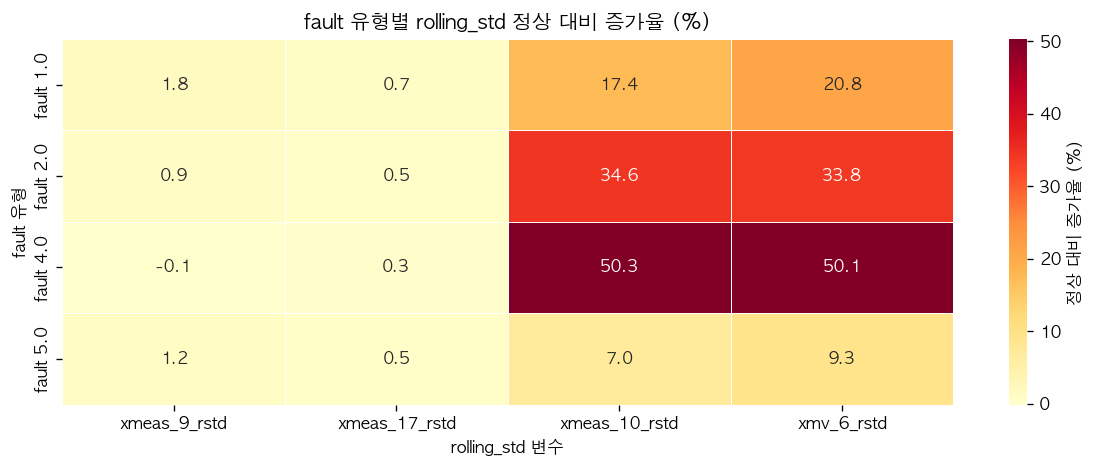

In [57]:
# ── 9-E. faultNumber별 rolling_std 평균 및 정상 대비 증가율 비교 ──

rstd_target_cols = [
    'xmeas_9_rstd',
    'xmeas_17_rstd',
    'xmeas_10_rstd',
    'xmv_6_rstd'
]

rstd_target_cols = [c for c in rstd_target_cols if c in dynamic_train.columns]

rstd_mean_by_fault = (
    dynamic_train
    .groupby('faultNumber')[rstd_target_cols]
    .mean()
)

rstd_mean_by_fault.index = [
    '정상' if i == 0 else f'fault {i}' for i in rstd_mean_by_fault.index
]

display(rstd_mean_by_fault)

normal_rstd = rstd_mean_by_fault.loc['정상']

rstd_increase_rate = (
    (rstd_mean_by_fault.drop(index='정상') - normal_rstd)
    / normal_rstd.replace(0, np.nan)
) * 100

display(rstd_increase_rate)

rstd_avg_increase = rstd_increase_rate.mean(axis=0).sort_values(ascending=False)

print('\n정상 대비 rolling_std 평균 증가율이 큰 변수 순서:')
print(rstd_avg_increase)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    rstd_increase_rate,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': '정상 대비 증가율 (%)'}
)
ax.set_title('fault 유형별 rolling_std 정상 대비 증가율 (%)', fontsize=12)
ax.set_xlabel('rolling_std 변수')
ax.set_ylabel('fault 유형')
plt.tight_layout()
plt.savefig('../outputs/01_rolling_std_increase_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. EDA 인사이트 요약
 
> - rolling_std / diff / z-score EDA 결과 반영


In [59]:
print('=' * 65)
print('EDA 인사이트 요약  (실제 분석 결과 기준)')
print('=' * 65)

n_train  = len(train_df)
n_normal = (train_df['label'] == 0).sum()
n_fault  = (train_df['label'] == 1).sum()

top_rstd_vars = rstd_avg_increase.head(2).index.tolist()
top_rstd_text = ', '.join(top_rstd_vars)

print(f'''
[데이터 현황]
  학습 데이터 : {n_train:,}행 × {len(FEATURE_COLS)}개 피처
  정상 샘플   : {n_normal:,}개 ({n_normal/n_train*100:.1f}%)
  이상 샘플   : {n_fault:,}개  ({n_fault/n_train*100:.1f}%)
  사용 fault  : {FAULT_TYPES}
  클래스 비율 : 정상 1 : 이상 {n_fault/n_normal:.1f}

[정적 피처 분석 결과]
  ■ 이상 민감도(효과크기) 상위 변수:
      xmeas_10 > xmv_6 > xmeas_34 > xmeas_28 > xmeas_1 > xmv_3
      → 평균값 기준으로는 xmeas_10, xmv_6 계열의 변화가 크게 나타남

  ■ 평균값 변화만으로는 부족한 변수:
      xmeas_9, xmeas_17은 공정적으로 중요한 온도 변수이지만,
      이번 평균 비교에서는 변화가 상대적으로 작게 나타남
      → 따라서 rolling_std, diff, z-score 기반 동적 피처로 추가 검토함

[동적 피처 분석 결과]
  ■ rolling_std 정상 대비 평균 증가율 상위 변수:
      {top_rstd_text}
      → 실제 수치 기반으로 변동성 증가가 큰 변수를 우선 후보로 선정

  ■ diff (1-step 차분):
      xmeas_10_diff, xmv_6_diff 등에서 급변 패턴 확인 가능

  ■ z-score:
      정상 기준 |z| > 3 이상값 밀도가 fault별로 다르게 나타남
      → 정상 운전 범위를 벗어나는 변수 후보를 확인하는 데 활용 가능

[해석상 주의점]
  ■ xmeas_9_rstd, xmeas_17_rstd는 동적 피처 후보로 검토했으나,
      실제 rolling_std 증가율 상위 여부는 9-E 표 결과를 기준으로 판단해야 함.
  ■ 따라서 최종 모델링에서는 사전 가정이 아니라,
      효과크기·z-score 밀도·rolling_std 증가율 결과를 함께 고려해 피처를 선정함.

[다음 단계 — 전처리 전략]
  1. simulationRun 기준 train/test 분리 유지
  2. StandardScaler는 train 기준 fit, test에는 transform만 적용
  3. 원본 52개 피처를 baseline으로 사용
  4. EDA에서 민감도가 높은 동적 피처를 추가하여 성능 개선 여부 비교
  5. 베이스라인은 Isolation Forest → XGBoost 순서로 진행
''')

print('\n저장된 그래프:')
for fname in [
    '01_class_distribution.png',
    '01_timeseries_comparison.png',
    '01_fault_comparison_heatmap.png',
    '01_boxplot_comparison.png',
    '01_correlation_heatmap.png',
    '01_zone_effect_size.png',
    '01_rolling_std_comparison.png',
    '01_zscore_outlier_density.png',
    '01_diff_distribution.png',
    '01_dynamic_feature_importance.png',
    '01_rolling_std_increase_rate.png',
]:
    print(f'  → outputs/{fname}')

EDA 인사이트 요약  (실제 분석 결과 기준)

[데이터 현황]
  학습 데이터 : 1,250,000행 × 52개 피처
  정상 샘플   : 250,000개 (20.0%)
  이상 샘플   : 1,000,000개  (80.0%)
  사용 fault  : [1, 2, 4, 5]
  클래스 비율 : 정상 1 : 이상 4.0

[정적 피처 분석 결과]
  ■ 이상 민감도(효과크기) 상위 변수:
      xmeas_10 > xmv_6 > xmeas_34 > xmeas_28 > xmeas_1 > xmv_3
      → 평균값 기준으로는 xmeas_10, xmv_6 계열의 변화가 크게 나타남

  ■ 평균값 변화만으로는 부족한 변수:
      xmeas_9, xmeas_17은 공정적으로 중요한 온도 변수이지만,
      이번 평균 비교에서는 변화가 상대적으로 작게 나타남
      → 따라서 rolling_std, diff, z-score 기반 동적 피처로 추가 검토함

[동적 피처 분석 결과]
  ■ rolling_std 정상 대비 평균 증가율 상위 변수:
      xmv_6_rstd, xmeas_10_rstd
      → 실제 수치 기반으로 변동성 증가가 큰 변수를 우선 후보로 선정

  ■ diff (1-step 차분):
      xmeas_10_diff, xmv_6_diff 등에서 급변 패턴 확인 가능

  ■ z-score:
      정상 기준 |z| > 3 이상값 밀도가 fault별로 다르게 나타남
      → 정상 운전 범위를 벗어나는 변수 후보를 확인하는 데 활용 가능

[해석상 주의점]
  ■ xmeas_9_rstd, xmeas_17_rstd는 동적 피처 후보로 검토했으나,
      실제 rolling_std 증가율 상위 여부는 9-E 표 결과를 기준으로 판단해야 함.
  ■ 따라서 최종 모델링에서는 사전 가정이 아니라,
      효과크기·z-score 밀도·rolling_std 증가율 결과를 함께 고려해 피처를 선정함.

[다음 단